In [ ]:
# ==========================================
# INSTALL
# ==========================================
!pip install -q transformers sentencepiece accelerate faiss-cpu \
sentence-transformers evaluate sacrebleu rouge-score matplotlib tqdm scikit-learn

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 57.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 3.9 MB/s eta 0:00:00


In [ ]:
# ==========================================
# IMPORTS
# ==========================================
import os
import gc
import json
import faiss
import torch
import evaluate
import sacrebleu
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, AutoModelForCausalLM

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ==========================================
# PATHS
# ==========================================
BASE_DIR = "/content/drive/MyDrive/MALAYALAM_RAG_PROJECT/sarvam_rag"

os.makedirs(BASE_DIR, exist_ok=True)

PRED_PATH = f"{BASE_DIR}/predictions.csv"
RESULTS_PATH = f"{BASE_DIR}/full_results.csv"
SUMMARY_PATH = f"{BASE_DIR}/summary_metrics.json"

In [ ]:
# ==========================================
# LOAD DATA
# ==========================================
train_df = pd.read_csv("/content/drive/MyDrive/train.csv")
valid_df = pd.read_csv("/content/drive/MyDrive/validation.csv")

train_df = train_df[["article", "summary"]].dropna()
valid_df = valid_df[["article", "summary"]].dropna()

print(train_df.shape)
print(valid_df.shape)

(7758, 2)
(970, 2)


In [ ]:
# ==========================================
# CHUNKING
# ==========================================
def chunk_text(text, chunk_size=1000, overlap=150):
    chunks = []
    start = 0

    while start < len(text):
        end = start + chunk_size
        chunks.append(text[start:end])
        start += chunk_size - overlap

    return chunks

In [ ]:
# ==========================================
# BUILD CORPUS
# ==========================================
all_chunks = []

for article in tqdm(train_df["article"]):
    article = str(article)
    chunks = chunk_text(article)
    all_chunks.extend(chunks)

chunk_df = pd.DataFrame({"chunk": all_chunks})

print("Total chunks:", len(chunk_df))

100%|██████████| 7758/7758 [00:00<00:00, 1020556.09it/s]

Total chunks: 7809


In [ ]:
# ==========================================
# EMBEDDING MODEL
# ==========================================
embedding_model = SentenceTransformer(
    "intfloat/multilingual-e5-base",
    device="cuda" if torch.cuda.is_available() else "cpu"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/418 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/200 [00:00<?, ?B/s]

In [ ]:
# ==========================================
# EMBEDDINGS
# ==========================================
BATCH_SIZE = 64
all_embeddings = []

chunk_texts = chunk_df["chunk"].tolist()

for i in tqdm(range(0, len(chunk_texts), BATCH_SIZE)):
    batch = chunk_texts[i:i+BATCH_SIZE]

    emb = embedding_model.encode(
        batch,
        convert_to_numpy=True,
        normalize_embeddings=True,
        show_progress_bar=False
    )

    all_embeddings.append(emb)

embeddings = np.vstack(all_embeddings)

print(embeddings.shape)

100%|██████████| 123/123 [00:57<00:00,  2.14it/s]

(7809, 768)


In [ ]:
# ==========================================
# FAISS INDEX
# ==========================================
dimension = embeddings.shape[1]

index = faiss.IndexFlatIP(dimension)
index.add(embeddings)

print("FAISS ready")

FAISS ready


In [ ]:
# ==========================================
# RETRIEVAL
# ==========================================
def retrieve_context(query, top_k=2):
    q_emb = embedding_model.encode(
        [query],
        convert_to_numpy=True,
        normalize_embeddings=True
    )

    scores, indices = index.search(q_emb, top_k)

    contexts = [
        chunk_df.iloc[idx]["chunk"]
        for idx in indices[0]
    ]

    return contexts

In [ ]:
# ==========================================
# LOAD SARVAM
# ==========================================
gc.collect()
torch.cuda.empty_cache()

MODEL_NAME = "sarvamai/sarvam-2b-v0.5"

device = "cuda" if torch.cuda.is_available() else "cpu"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto"
)

model.eval()

config.json:   0%|          | 0.00/706 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/1.70M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/255 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(64128, 2048)
    (layers): ModuleList(
      (0-27): 28 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (k_proj): Linear(in_features=2048, out_features=1024, bias=False)
          (v_proj): Linear(in_features=2048, out_features=1024, bias=False)
          (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=2048, out_features=11008, bias=False)
          (up_proj): Linear(in_features=2048, out_features=11008, bias=False)
          (down_proj): Linear(in_features=11008, out_features=2048, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((2048,), eps=1e-05)
   

In [ ]:
# ==========================================
# PROMPT
# ==========================================
def build_prompt(article, contexts):
    context_text = "\n".join(contexts)

    return f"""
നിങ്ങൾ ഒരു മലയാളം വാർത്താ സംഗ്രഹ നിർമാതാവാണ്.

പശ്ചാത്തല വിവരം:
{context_text}

ലേഖനം:
{article}

മലയാളത്തിൽ ചുരുക്കമായ സംഗ്രഹം മാത്രം നൽകുക:

"""

In [ ]:
# ==========================================
# GENERATION
# ==========================================
def generate_summary(article):
    article = str(article)

    contexts = retrieve_context(article, top_k=2)

    prompt = build_prompt(article, contexts)

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=2048
    ).to(device)

    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=80,
            do_sample=False,
            num_beams=4,
            repetition_penalty=1.5,
            no_repeat_ngram_size=3,
            early_stopping=True,
            pad_token_id=tokenizer.eos_token_id
        )

    pred = tokenizer.decode(
        output[0],
        skip_special_tokens=True
    )

    pred = pred.replace(prompt, "").strip()

    return pred, contexts

In [ ]:
# ==========================================
# GENERATION
# ==========================================
def generate_summary(article):
    article = str(article)

    contexts = retrieve_context(article, top_k=2)

    prompt = build_prompt(article, contexts)

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=2048
    ).to(device)

    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=80,
            do_sample=False,
            num_beams=4,
            repetition_penalty=1.5,
            no_repeat_ngram_size=3,
            early_stopping=True,
            pad_token_id=tokenizer.eos_token_id
        )

    pred = tokenizer.decode(
        output[0],
        skip_special_tokens=True
    )

    pred = pred.replace(prompt, "").strip()

    return pred, contexts

In [ ]:
# ==========================================
# FULL PREDICTION LOOP
# ==========================================
articles = []
references = []
predictions = []
retrieved_1 = []
retrieved_2 = []

RUN_ROWS = len(valid_df)

# for testing:
# RUN_ROWS = 50

subset = valid_df.iloc[:RUN_ROWS]

In [ ]:
# ==========================================
# GENERATE
# ==========================================
for _, row in tqdm(subset.iterrows(), total=len(subset)):
    article = str(row["article"])
    reference = str(row["summary"])

    try:
        pred, contexts = generate_summary(article)

        ctx1 = contexts[0] if len(contexts) > 0 else ""
        ctx2 = contexts[1] if len(contexts) > 1 else ""

    except Exception as e:
        print("Error:", e)

        pred = ""
        ctx1 = ""
        ctx2 = ""

    articles.append(article)
    references.append(reference)
    predictions.append(pred)
    retrieved_1.append(ctx1)
    retrieved_2.append(ctx2)

    torch.cuda.empty_cache()

100%|██████████| 970/970 [59:05<00:00,  3.66s/it]


In [ ]:
# ==========================================
# SAVE PREDICTIONS
# ==========================================
pred_df = pd.DataFrame({
    "article": articles,
    "reference": references,
    "retrieved_context_1": retrieved_1,
    "retrieved_context_2": retrieved_2,
    "prediction": predictions
})

pred_df.to_csv(
    PRED_PATH,
    index=False,
    encoding="utf-8-sig"
)

print("Saved:", PRED_PATH)

Saved: /content/drive/MyDrive/MALAYALAM_RAG_PROJECT/sarvam_rag/predictions.csv


In [ ]:
# ==========================================
# SAMPLE CHECK
# ==========================================
display(pred_df.sample(5))

,article,reference,retrieved_context_1,retrieved_context_2,prediction
272,വയനാട് : ഗോത്രവര്ഗ്ഗ വിദ്യാര്ഥികള് ഇച്ഛാശക്തി ...,നല്ലൂര്നാട് അംബേദ്കര് മോഡല് റെസിഡന്ഷ്യല് സ്കൂള...,പാലക്കാട്: പൊതുവിദ്യാഭ്യാസ സംരക്ഷണയജ്ഞത്തിലൂടെ...,കാസര്ഗോഡ്: ജീവിതത്തില് എ പ്ലസ് നേടുക എന്നതാകണം...,1. പൊതു വിദ്യാഭ്യാസ സംരക്ഷണ യജ്ഞം ഫലപ്രദമായി ന...
724,നിശാഗന്ധികള് പൂക്കുമ്പോള് ഇന്നലെ ആദ്യം ആയി തിര...,പുഴ.കോം - നവസംസ്കൃതിയുടെ ജലസമൃദ്ധി,തിരുവനന്തപുരം : മനംമയക്കുന്ന നിറക്കാഴ്ചകളൊരുക്...,ഇന്നലെ നിശീഥത്തിലൊരു പൊൻകിനാവിൽ ഞാൻ കണ്ടു ഭാരത...,1. മലയാളത്തിലെ ഏറ്റവും വലിയ ഉത്സവമായ നിശാഗ്ധിക...
689,ദുബായ്: യുഎഇയുടെ ഹസ്സ അൽ മൻസൂറിക്ക് രാജ്യാന്തര...,യുഎഇയുടെ ഹസ്സക്ക് ബഹിരാകാശ നിലയത്തിൽ പരീക്ഷണ ന...,ജിദ്ദ: സൗദിയിലെ അബഹ അന്താരാഷ്ട്ര വിമാനത്താവളത്...,തിരുവനന്തപുരം: അറബിക്കടലിൽ 'മഹാ' ചുഴലിക്കാറ്റ്...,1. ദുബായിലെ യു. എ. ഇ. യുടെ ഹസ അൽ മാൻസൂരിക്ക് അ...
850,ഇന്ത്യയുടെ പേസ് ബൗളര് എന്ന വിശേഷണങ്ങളാല് അറിയപ...,അനുപമ പരമേശ്വരനെ അൺഫോളോ ചെയ്ത് ബുമ്ര.! കാരണം ഇ...,കളിക്കളത്തിലെ പ്രതിഷേധങ്ങളുടെ പേരിൽ പലപ്പോഴും ...,്രത്തില് ദുല്ഖര് അവതരിപ്പിക്കുന്നത് ഇന്ത്യന് ക...,ക്രിക്കറ്റിലെ ഏറ്റവും മികച്ച ബാറ്റ്സ്മാൻമാരിൽ ...
500,ജീവിതംനീളെ യാത്രചെയ്ത് ഒടുവിൽ അയാൾ ഒരു പുഴവക്ക...,പുഴ.കോം - നവസംസ്കൃതിയുടെ ജലസമൃദ്ധി,ഒരു ദിവസം പൊന്നൻമുയൽ ആഹാരം തേടി കാട്ടാറിന്റെ ത...,പാട്ടുപേക്ഷിച്ച ചെരുപ്പുകുത്തി ഒരു ചെരുപ്പുകുത...,1. പാട്ടുപാടിക്കൊണ്ടിരുന്ന ഒരു ചെറുക്കുട്ടി വഴ...


In [ ]:
# ==========================================
# CLEANUP BEFORE METRICS
# ==========================================
gc.collect()
torch.cuda.empty_cache()

In [ ]:
# ==========================================
# LOAD PRED CSV
# ==========================================
pred_df = pd.read_csv(PRED_PATH)
pred_df = pred_df.fillna("")

articles = pred_df["article"].astype(str).tolist()
references = pred_df["reference"].astype(str).tolist()
predictions = pred_df["prediction"].astype(str).tolist()

retrieved1 = pred_df["retrieved_context_1"].astype(str).tolist()
retrieved2 = pred_df["retrieved_context_2"].astype(str).tolist()

retrieved_contexts = [
    r1 + " " + r2
    for r1, r2 in zip(retrieved1, retrieved2)
]

In [ ]:
# ==========================================
# ROUGE + BLEU
# ==========================================
rouge = evaluate.load("rouge")

rouge_scores = rouge.compute(
    predictions=predictions,
    references=references
)

bleu = sacrebleu.corpus_bleu(
    predictions,
    [references]
).score

In [ ]:
# ==========================================
# SEMANTIC BERTSCORE APPROX
# ==========================================
pred_emb = embedding_model.encode(
    predictions,
    batch_size=16,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

ref_emb = embedding_model.encode(
    references,
    batch_size=16,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

bert_per_sample = np.sum(pred_emb * ref_emb, axis=1)
bertscore = bert_per_sample.mean()

Batches:   0%|          | 0/61 [00:00<?, ?it/s]

Batches:   0%|          | 0/61 [00:00<?, ?it/s]

In [ ]:
# ==========================================
# FAITHFULNESS
# ==========================================
ctx_emb = embedding_model.encode(
    retrieved_contexts,
    batch_size=16,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

faithfulness_scores = np.sum(pred_emb * ctx_emb, axis=1)
faithfulness = faithfulness_scores.mean()

Batches:   0%|          | 0/61 [00:00<?, ?it/s]

In [ ]:
# ==========================================
# CONTEXT PRECISION
# ==========================================
cp_scores = []

for pred, ctx in tqdm(zip(predictions, retrieved_contexts), total=len(predictions)):
    pred_sentences = pred.split(".")

    if len(pred_sentences) == 0:
        cp_scores.append(0)
        continue

    ctx_emb_local = embedding_model.encode(
        ctx,
        convert_to_numpy=True,
        normalize_embeddings=True
    )

    supported = 0
    valid_sent = 0

    for sent in pred_sentences:
        sent = sent.strip()

        if len(sent) < 5:
            continue

        valid_sent += 1

        sent_emb = embedding_model.encode(
            sent,
            convert_to_numpy=True,
            normalize_embeddings=True
        )

        sim = np.dot(sent_emb, ctx_emb_local)

        if sim > 0.65:
            supported += 1

    cp = supported / max(valid_sent, 1)
    cp_scores.append(cp)

cp_scores = np.array(cp_scores)
context_precision = cp_scores.mean()

100%|██████████| 970/970 [00:43<00:00, 22.38it/s]


In [ ]:
# ==========================================
# CONTEXT RECALL
# ==========================================
cr_scores = []

for pred, ctx in tqdm(zip(predictions, retrieved_contexts), total=len(predictions)):
    ctx_chunks = [c for c in ctx.split("\n") if len(c.strip()) > 20]

    pred_emb_local = embedding_model.encode(
        pred,
        convert_to_numpy=True,
        normalize_embeddings=True
    )

    covered = 0

    for chunk in ctx_chunks:
        chunk_emb = embedding_model.encode(
            chunk,
            convert_to_numpy=True,
            normalize_embeddings=True
        )

        sim = np.dot(pred_emb_local, chunk_emb)

        if sim > 0.65:
            covered += 1

    cr = covered / max(len(ctx_chunks), 1)
    cr_scores.append(cr)

cr_scores = np.array(cr_scores)
context_recall = cr_scores.mean()

100%|██████████| 970/970 [00:25<00:00, 38.67it/s]


In [ ]:
# ==========================================
# HALLUCINATION SCORE
# ==========================================
hallucination_scores = 1 - (
    0.4 * faithfulness_scores +
    0.2 * cp_scores +
    0.2 * cr_scores +
    0.2 * bert_per_sample
)

hallucination_rate = (hallucination_scores > 0.5).mean()

In [ ]:
# ==========================================
# SUMMARY METRICS
# ==========================================
summary_metrics = {
    "rouge1": float(rouge_scores["rouge1"]),
    "rouge2": float(rouge_scores["rouge2"]),
    "rougeL": float(rouge_scores["rougeL"]),
    "bleu": float(bleu),
    "bertscore": float(bertscore),

    "faithfulness": float(faithfulness),
    "context_precision": float(context_precision),
    "context_recall": float(context_recall),

    "hallucination_score": float(hallucination_scores.mean()),
    "hallucination_rate": float(hallucination_rate)
}

print(summary_metrics)

{'rouge1': 0.0054622811323842245, 'rouge2': 0.0, 'rougeL': 0.0055277368679430535, 'bleu': 0.26163129606160535, 'bertscore': 0.8200801014900208, 'faithfulness': 0.8613624572753906, 'context_precision': 1.0, 'context_recall': 1.0, 'hallucination_score': 0.09143898785114297, 'hallucination_rate': 0.0}


In [ ]:
# ==========================================
# SAVE FULL RESULTS
# ==========================================
full_df = pd.DataFrame({
    "article": articles,
    "reference": references,
    "prediction": predictions,

    "bertscore": bert_per_sample,
    "faithfulness": faithfulness_scores,
    "context_precision": cp_scores,
    "context_recall": cr_scores,
    "hallucination_score": hallucination_scores
})

full_df.to_csv(
    RESULTS_PATH,
    index=False,
    encoding="utf-8-sig"
)

In [ ]:
# ==========================================
# SAVE JSON
# ==========================================
with open(SUMMARY_PATH, "w") as f:
    json.dump(summary_metrics, f, indent=4)

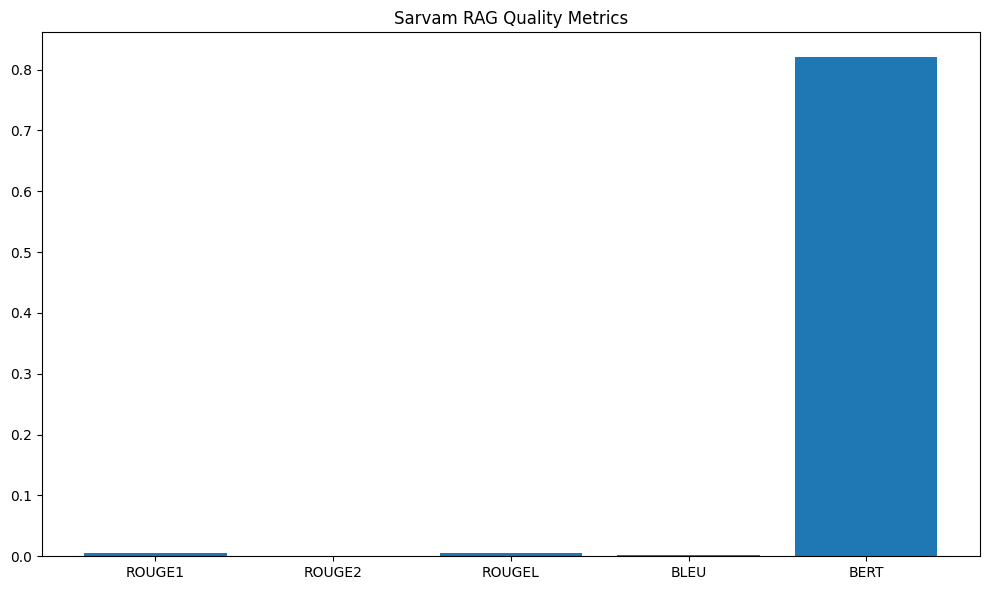

In [ ]:
# ==========================================
# QUALITY PLOT
# ==========================================
plt.figure(figsize=(10,6))

quality_names = ["ROUGE1","ROUGE2","ROUGEL","BLEU","BERT"]
quality_vals = [
    summary_metrics["rouge1"],
    summary_metrics["rouge2"],
    summary_metrics["rougeL"],
    summary_metrics["bleu"]/100,
    summary_metrics["bertscore"]
]

plt.bar(quality_names, quality_vals)
plt.title("Sarvam RAG Quality Metrics")
plt.tight_layout()
plt.savefig(f"{BASE_DIR}/quality_metrics.png")
plt.show()

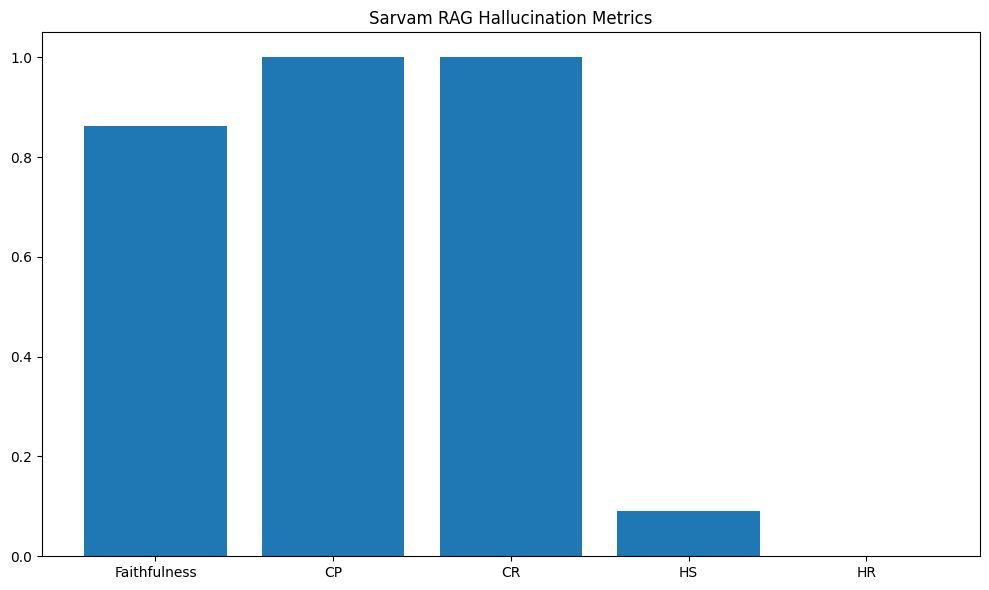

In [ ]:
# ==========================================
# HALLUCINATION PLOT
# ==========================================
plt.figure(figsize=(10,6))

hall_names = ["Faithfulness","CP","CR","HS","HR"]
hall_vals = [
    summary_metrics["faithfulness"],
    summary_metrics["context_precision"],
    summary_metrics["context_recall"],
    summary_metrics["hallucination_score"],
    summary_metrics["hallucination_rate"]
]

plt.bar(hall_names, hall_vals)
plt.title("Sarvam RAG Hallucination Metrics")
plt.tight_layout()
plt.savefig(f"{BASE_DIR}/hallucination_metrics.png")
plt.show()

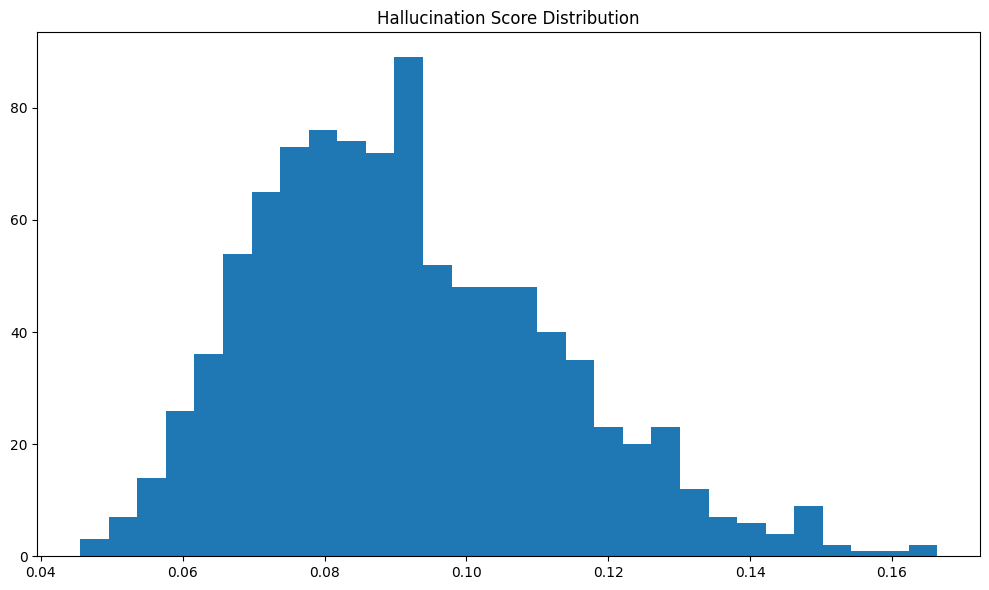

In [ ]:
# ==========================================
# DISTRIBUTION
# ==========================================
plt.figure(figsize=(10,6))
plt.hist(hallucination_scores, bins=30)
plt.title("Hallucination Score Distribution")
plt.tight_layout()
plt.savefig(f"{BASE_DIR}/hallucination_distribution.png")
plt.show()

In [ ]:
# ==========================================
# CLEANUP
# ==========================================
del model
del tokenizer
gc.collect()
torch.cuda.empty_cache()